# Phase 0 — PTB-XL EDA + Preprocessing

This notebook does two things:
1. EDA on PTB-XL metadata and diagnostic classes
2. Preprocessing for Phase 1 single-label baseline training

Expected dataset path: `../../dataset/raw/ptb-xl/`
Fallback path: `../../../ptb-xl/`

In [10]:
import pandas as pd

df = pd.read_csv("../../../ptb-xl/ptbxl_database.csv")
list(df.columns)

['ecg_id',
 'patient_id',
 'age',
 'sex',
 'height',
 'weight',
 'nurse',
 'site',
 'device',
 'recording_date',
 'report',
 'scp_codes',
 'heart_axis',
 'infarction_stadium1',
 'infarction_stadium2',
 'validated_by',
 'second_opinion',
 'initial_autogenerated_report',
 'validated_by_human',
 'baseline_drift',
 'static_noise',
 'burst_noise',
 'electrodes_problems',
 'extra_beats',
 'pacemaker',
 'strat_fold',
 'filename_lr',
 'filename_hr']

In [11]:
from pathlib import Path
import ast
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    import wfdb
except Exception:
    wfdb = None

from sklearn.preprocessing import LabelEncoder

PROJECT_ROOT = Path('../../').resolve()
RAW_DIR = PROJECT_ROOT / 'dataset' / 'raw' / 'ptb-xl'
if not RAW_DIR.exists():
    fallback = Path('../../../ptb-xl').resolve()
    if fallback.exists():
        RAW_DIR = fallback

PROCESSED_DIR = PROJECT_ROOT / 'dataset' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('RAW_DIR:', RAW_DIR)
print('PROCESSED_DIR:', PROCESSED_DIR)
print('wfdb available:', wfdb is not None)

PROJECT_ROOT: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence
RAW_DIR: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/raw/ptb-xl
PROCESSED_DIR: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/processed
wfdb available: True


In [12]:
ptbxl_csv = RAW_DIR / 'ptbxl_database.csv'
scp_csv = RAW_DIR / 'scp_statements.csv'

if not ptbxl_csv.exists() or not scp_csv.exists():
    raise FileNotFoundError('Could not find PTB-XL CSV files in RAW_DIR.')

meta = pd.read_csv(ptbxl_csv)
scp = pd.read_csv(scp_csv, index_col=0)

meta['scp_codes'] = meta['scp_codes'].apply(ast.literal_eval)
diag_df = scp[scp['diagnostic'] == 1]

def to_superclasses(code_dict):
    labels = []
    for code in code_dict.keys():
        if code in diag_df.index:
            label = diag_df.loc[code, 'diagnostic_class']
            if pd.notna(label):
                labels.append(label)
    return sorted(set(labels))

meta['diagnostic_superclass'] = meta['scp_codes'].apply(to_superclasses)
meta = meta[meta['diagnostic_superclass'].map(len) > 0].copy()

meta['target_label'] = meta['diagnostic_superclass'].apply(lambda x: x[0])
meta[['ecg_id', 'filename_lr', 'strat_fold', 'target_label']].head()

,ecg_id,filename_lr,strat_fold,target_label
0,1,records100/00000/00001_lr,3,NORM
1,2,records100/00000/00002_lr,2,NORM
2,3,records100/00000/00003_lr,5,NORM
3,4,records100/00000/00004_lr,3,NORM
4,5,records100/00000/00005_lr,4,NORM


Rows after filtering: 21430
Unique target labels: ['CD', 'HYP', 'MI', 'NORM', 'STTC']


target_label
NORM    9111
CD      4907
MI      3140
STTC    2406
HYP     1866
Name: count, dtype: int64

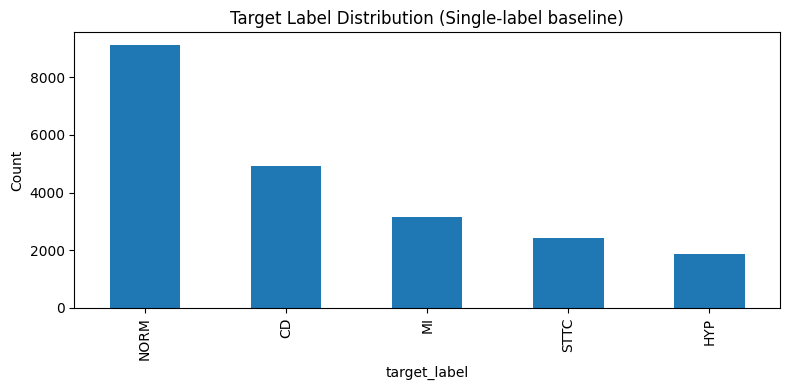

In [13]:
print('Rows after filtering:', len(meta))
print('Unique target labels:', sorted(meta['target_label'].unique()))

label_counts = meta['target_label'].value_counts()
display(label_counts)

plt.figure(figsize=(8, 4))
label_counts.plot(kind='bar')
plt.title('Target Label Distribution (Single-label baseline)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Preprocessing settings

- `MAX_SAMPLES`: set to `None` to use all records
- split uses PTB-XL `strat_fold`:
  - train: folds 1..8
  - val: fold 9
  - test: fold 10

In [14]:
if wfdb is None:
    raise ImportError('wfdb is required to load ECG signals. Install with: pip install wfdb')

MAX_SAMPLES = 3000
working = meta.copy()
if MAX_SAMPLES is not None:
    working = working.sample(n=min(MAX_SAMPLES, len(working)), random_state=42).copy()

label_encoder = LabelEncoder()
working['target_id'] = label_encoder.fit_transform(working['target_label'])
label_map = {int(i): cls for i, cls in enumerate(label_encoder.classes_)}

def load_signal(rel_path):
    record_path = RAW_DIR / rel_path
    signal, _ = wfdb.rdsamp(str(record_path))
    return signal.astype(np.float32)

X = []
y = []
folds = []

for _, row in working.iterrows():
    try:
        sig = load_signal(row['filename_lr'])
        if sig.shape == (1000, 12):
            X.append(sig)
            y.append(int(row['target_id']))
            folds.append(int(row['strat_fold']))
    except Exception:
        pass

X = np.array(X, dtype=np.float32)
y = np.array(y, dtype=np.int64)
folds = np.array(folds, dtype=np.int64)

print('Loaded X shape:', X.shape)
print('Loaded y shape:', y.shape)
print('Classes:', label_map)

Loaded X shape: (3000, 1000, 12)
Loaded y shape: (3000,)
Classes: {0: 'CD', 1: 'HYP', 2: 'MI', 3: 'NORM', 4: 'STTC'}


In [15]:
train_mask = folds <= 8
val_mask = folds == 9
test_mask = folds == 10

X_train, y_train = X[train_mask], y[train_mask]
X_val, y_val = X[val_mask], y[val_mask]
X_test, y_test = X[test_mask], y[test_mask]

np.save(PROCESSED_DIR / 'X_train.npy', X_train)
np.save(PROCESSED_DIR / 'y_train.npy', y_train)
np.save(PROCESSED_DIR / 'X_val.npy', X_val)
np.save(PROCESSED_DIR / 'y_val.npy', y_val)
np.save(PROCESSED_DIR / 'X_test.npy', X_test)
np.save(PROCESSED_DIR / 'y_test.npy', y_test)

with open(PROCESSED_DIR / 'label_map.json', 'w', encoding='utf-8') as f:
    json.dump(label_map, f, indent=2)

summary = {
    'n_train': int(len(y_train)),
    'n_val': int(len(y_val)),
    'n_test': int(len(y_test)),
    'classes': label_map
}
with open(PROCESSED_DIR / 'preprocess_summary.json', 'w', encoding='utf-8') as f:
    json.dump(summary, f, indent=2)

print('Saved processed files to:', PROCESSED_DIR)
summary

Saved processed files to: /Users/ayoub/work/MS-DS_ML_Projects/IOT/collective-intelligence/dataset/processed


{'n_train': 2382,
 'n_val': 313,
 'n_test': 305,
 'classes': {0: 'CD', 1: 'HYP', 2: 'MI', 3: 'NORM', 4: 'STTC'}}

## Next

Run Phase 1 training:

`python phase1/models/train_phase1_cnn.py --data-dir dataset/processed --out-dir results/phase1 --epochs 10`